# Objective
The objective of this analysis is to evaluate pricing strategy across key business dimensions: price positioning, margin realization, and cost efficiency in order to:

- Analyze performance of different price bands in terms of revenue and margin contribution
- Examine pricing behavior by comparing sales price and purchase price to understand markup realization
- Assess consistency of markup across pack sizes and price segments to detect pricing inconsistencies
- Evaluate whether bulk purchasing leads to reduction in unit cost
- Identify products where pricing is not aligned with demand (sell-through vs markup imbalance)
- Compare vendor provided margins with price segment benchmarks to identify negotiation gaps

This enables data-driven decision making for pricing optimization, margin improvement, and vendor negotiation, ultimately improving both profitability and sales efficiency.

### Importing libraries

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sqlalchemy import create_engine,text
from sqlalchemy.engine import URL
import os
from dotenv import load_dotenv

### Connection setup and Reading required datasets

In [2]:
# load env file and import credentials
load_dotenv()
DB_USER = os.getenv("DB_USER")
DB_HOST = os.getenv("DB_HOST")
DB_PASSWORD = os.getenv("DB_PASSWORD")

# establish connection to the 'inventory_db' database
conn_url = URL.create (
    drivername = "mysql+pymysql",
    host = DB_HOST,
    username = DB_USER,
    password = DB_PASSWORD,
    database = 'inventory_db'
)
conn_eng = create_engine(conn_url)
print("Connection Open to 'inventory_db' database")

Connection Open to 'inventory_db' database


In [3]:
# reading required datasets from the database
with conn_eng.connect() as conn:
    dataset   = pd.read_sql(text("select * from product_summary;"), conn)
    begin_inv = pd.read_sql(text('''select ProductId,sum(onHand) as BeginningInv
                                    from begin_inventory
                                    group by ProductId'''),conn)
    purchase_trans  = pd.read_sql(text('''select 
                                      PONumber,
                                      sum(Quantity) as PurchaseQuantity,
                                      sum(Dollars) as PurchaseDollars
                                      from purchases group by PONumber;'''),conn)

print("(Rows, Columns) :",dataset.shape)
dataset.head(3)

(Rows, Columns) : (10485, 14)


,ProductId,Description,VendorNumber,VendorName,Volume_ml,ActualPrice,PurchasePrice,TotalQuantityPurchased,TotalPurchaseDollars,SalesPrice,TotalQuantitySold,TotalSalesDollars,GrossProfit,GrossProfitMargin
0,58,Gekkeikan Black & Gold Sake,8320,SHAW ROSS INT L IMP LTD,750,12.99,9.28,3550,32944.0,12.58,3446,43341.54,11362.66,26.22
1,62,Herradura Silver Tequila,1128,BROWN-FORMAN CORP,750,36.99,28.67,3200,91744.0,38.36,3125,119863.75,30270.00,25.25
2,63,Herradura Reposado Tequila,1128,BROWN-FORMAN CORP,750,38.99,30.46,2855,86963.3,40.41,2778,112249.22,27631.34,24.62


In [4]:
dataset = dataset.merge(begin_inv, on='ProductId', how='left')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10485 entries, 0 to 10484
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ProductId               10485 non-null  int64  
 1   Description             10485 non-null  object 
 2   VendorNumber            10485 non-null  int64  
 3   VendorName              10485 non-null  object 
 4   Volume_ml               10485 non-null  int64  
 5   ActualPrice             10485 non-null  float64
 6   PurchasePrice           10485 non-null  float64
 7   TotalQuantityPurchased  10485 non-null  int64  
 8   TotalPurchaseDollars    10485 non-null  float64
 9   SalesPrice              10485 non-null  float64
 10  TotalQuantitySold       10485 non-null  int64  
 11  TotalSalesDollars       10485 non-null  float64
 12  GrossProfit             10485 non-null  float64
 13  GrossProfitMargin       10485 non-null  float64
 14  BeginningInv            7272 non-null 

### Data Preparation

In [5]:
# Preparing summary dataset for analysis
product_summary = dataset.groupby(['Description','Volume_ml']).agg({
    'ActualPrice' : 'mean',
    'PurchasePrice' : 'mean',
    'SalesPrice' : 'mean',
    'TotalQuantityPurchased' : 'sum',
    'TotalQuantitySold' : 'sum',
    'TotalPurchaseDollars' : 'sum',
    'TotalSalesDollars' : 'sum',
    'GrossProfit' : 'sum',
    'BeginningInv' : 'sum'
}).reset_index()
product_summary.head(3)

,Description,Volume_ml,ActualPrice,PurchasePrice,SalesPrice,TotalQuantityPurchased,TotalQuantitySold,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,BeginningInv
0,(RI) 1,750,36.99,26.92,36.41,655,591,17632.60,21519.09,5609.37,225.0
1,.nparalleled Svgn Blanc,750,7.99,5.36,7.99,143,137,766.48,1094.63,360.31,0.0
2,10 Span Cab Svgn CC,750,7.49,4.96,7.49,431,361,2137.76,2703.89,913.33,0.0


In [6]:
# Calculated Columns for deeper analysis

# Gross Profit Margin= Gross Profit*100 / Revenue
product_summary['GrossProfitMargin']=(product_summary['GrossProfit']*100/product_summary['TotalSalesDollars']).round(2)

# Sell Through Ratio = Qty Sold / Available Qty
product_summary['SellThroughRatio']=(product_summary['TotalQuantitySold']/
                                    (product_summary['TotalQuantityPurchased'] +
                                     product_summary['BeginningInv'])).round(2)

# Revenue, Procurement and Profit Share
product_summary['SalesContribution'] = (product_summary['TotalSalesDollars']*100 /
                                      product_summary['TotalSalesDollars'].sum())

product_summary['PurchaseContribution'] = (product_summary['TotalPurchaseDollars']*100 /
                                      product_summary['TotalPurchaseDollars'].sum())

product_summary['ProfitContribution'] = (product_summary['GrossProfit']*100 /
                                      product_summary['GrossProfit'].sum())


In [7]:
# Pack Size Segment
bins = [0,375,750,2000,float('inf')]
labels = ['Small','Standard','Large','Bulk']

product_summary['SizeSegment'] = pd.cut(product_summary['Volume_ml'], bins= bins, labels= labels)
product_summary['SizeSegment'].value_counts().reset_index(name = 'No_of_Products')

,SizeSegment,No_of_Products
0,Standard,8409
1,Large,1206
2,Small,684
3,Bulk,163


In [8]:
# user defined function to format currency values
def format_currency(value):
    if abs(value) >= 1000_000:
        return f"${round(value/1000_000,2)}M"
    elif abs(value) >= 1000:
        return f"${round(value/1000,2)}K"
    else:
        return f"${round(value,2)}"

#### Price Band wise Peformance

In [9]:
# Sales Price per ml = Sales Price / Volume Size(ml)
product_summary['SalesPrice_perml'] = product_summary['SalesPrice']/ product_summary['Volume_ml']

# Segmentation based on Sales Price per ml
product_summary['PriceSegment'] = pd.qcut(product_summary['SalesPrice_perml'], q=[0,0.4,0.75,0.95,1], 
                                        labels= ['Budget', 'Mid-range', 'Premium', 'Luxury'])
product_summary['PriceSegment'].value_counts().reset_index(name = 'No_of_Products')

,PriceSegment,No_of_Products
0,Budget,4185
1,Mid-range,3661
2,Premium,2099
3,Luxury,517


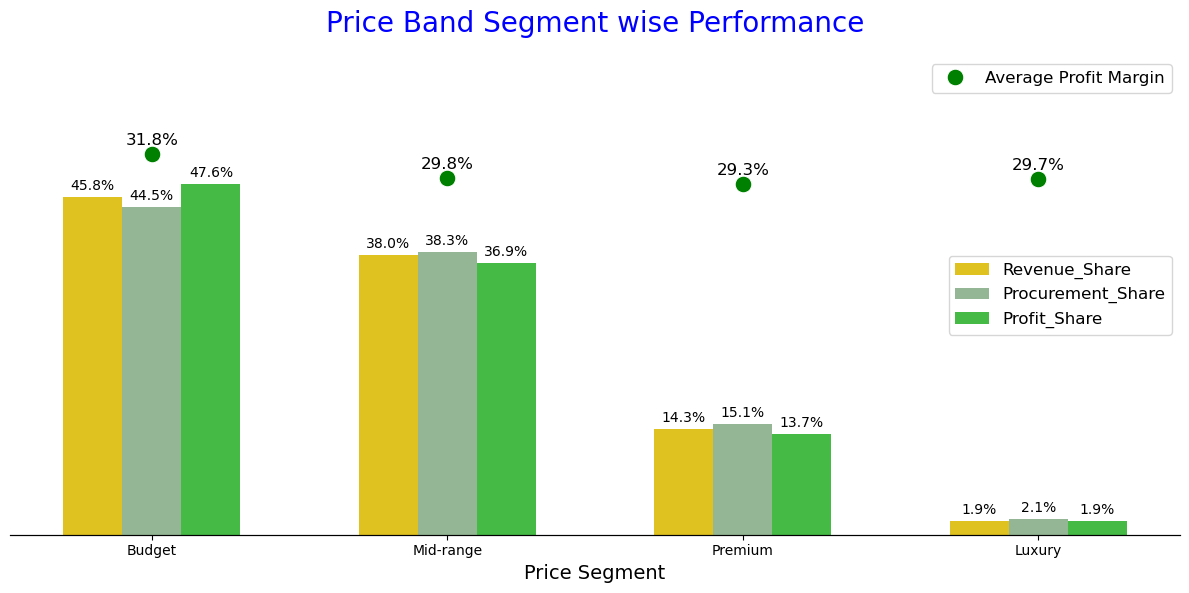

In [10]:
# Revenue, Procurement and Profit Share per segment
grouped_segment = product_summary.groupby('PriceSegment',observed=False).agg(
        Revenue_Share = ('SalesContribution' , 'sum'),
        Procurement_Share = ('PurchaseContribution' , 'sum'),
        Profit_Share = ('ProfitContribution' , 'sum')
    ).round(2).reset_index()

grouped_segment=grouped_segment.melt( id_vars='PriceSegment',
                    value_vars=['Revenue_Share','Procurement_Share',
                                'Profit_Share'],
                    var_name='Metric',value_name='Contribution')

fig,ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=grouped_segment, x='PriceSegment', y='Contribution',
                  hue='Metric', palette=['gold','darkseagreen','limegreen'], width=0.6 ,ax=ax1)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', padding=3)

ax1.set_xlabel('Price Segment', fontsize=14)
ax1.set_ylabel('')
ax1.legend(loc= 'center right', fontsize=12)
ax1.set_yticks([])
ax1.set_ylim(0,65)

ax2=ax1.twinx()
df_plot = product_summary.groupby('PriceSegment', observed=False).apply(
            lambda x: x['GrossProfit'].sum()*100 / x['TotalSalesDollars'].sum(), include_groups=False
            ).reset_index(name='GrossProfitMargin')
sns.lineplot(data=df_plot, x='PriceSegment', y='GrossProfitMargin', color='lightgreen',label= 'Average Profit Margin',
            marker='o',  markersize=12 , markerfacecolor= 'green', linestyle = 'None', ax=ax2)
for i,txt in enumerate(df_plot['GrossProfitMargin']):
    ax2.text(i, txt+0.5, f'{round(txt,1)}%', ha='center', va='bottom', fontsize=12)

ax2.set_ylabel('')
ax2.set_yticks([])
ax2.set_xlabel('Pack Size Segment', fontsize=12)
ax2.set_ylim(0,40)
ax2.legend(fontsize =12 ,loc='upper right')

plt.suptitle('Price Band Segment wise Performance', color='blue', fontsize=20)
sns.despine(left=True)
plt.tight_layout()
plt.show()

> - As price band increases from Budget to Luxury, contribution declines such that Budget segment dominates across sales, purchases, and profit with strong margins, while higher price segments progressively lose share and fail to improve margins meaningfully.

> - Mid-range segment shows scale but weaker ROI , suggesting optimization through pricing, vendor negotiation, or cost control.

> - For higher price bands Premium and Luxury, margins remain flat ~ 29%, suggesting pricing strategy needs correction, as higher prices are not translating into higher margins.

#### Pricing Behaviour Analysis

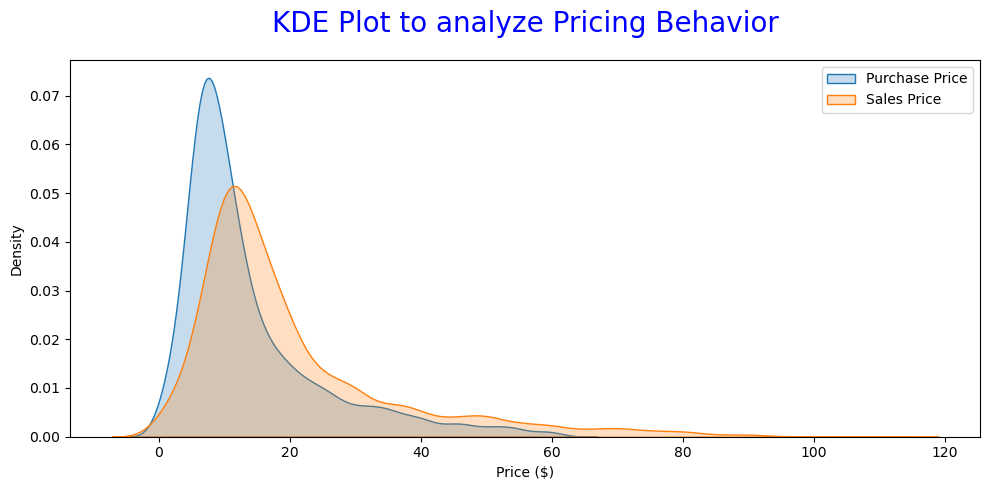

In [11]:
# Filtering extreme premium products and products with bulk storage volume
q = dataset['PurchasePrice'].quantile(0.95)
regular_products = product_summary[product_summary['PurchasePrice'] < q]

plt.figure(figsize=(10,5))

sns.kdeplot(data=regular_products['PurchasePrice'], fill=True ,label='Purchase Price')
sns.kdeplot(data=regular_products['SalesPrice'], fill=True, label='Sales Price')

plt.title('KDE Plot to analyze Pricing Behavior', color='blue',fontsize=20, pad=20)
plt.xlabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

 > - After removing extreme priced products, the KDE comparison between Purchase Price and Sales Price shows that sales prices are slightly shifted to the right, this confirms a positive markup strategy. 

> - But a substantial overlap is there between the distributions suggesting that that margins remain relatively narrow for most products, highlighting the need for targeted optimization of low margin segments. 


#### Markup Consistency Analysis across different Price Segments and Pack Size Segments

In [12]:
# Markup % = (Sales Price- Purchase Price)*100/ Purchase Price
product_summary['Markup_perc'] = ((product_summary['SalesPrice'] - product_summary['PurchasePrice'])*100 / 
                                product_summary['PurchasePrice'])

print(f'Average Markup % across products is {product_summary['Markup_perc'].mean().round(1)}%.')

print("Average Markup % Pack Size wise :")
display((product_summary.groupby('SizeSegment', observed=False).apply(
    lambda x:((x['SalesPrice'].sum()-x['PurchasePrice'].sum())/x['PurchasePrice'].sum())*100,include_groups=False)
    .round(1).astype(str) + '%').reset_index(name='Markup_perc'))

Average Markup % across products is 48.8%.
Average Markup % Pack Size wise :


,SizeSegment,Markup_perc
0,Small,41.7%
1,Standard,44.6%
2,Large,40.7%
3,Bulk,51.6%


> - The average markup varies moderately across size segments, ranging from 40.7% to 51.6%, indicating differentiated pricing rather than a uniform margin strategy.  
> - Standard pack size (44.6%) has the highest markup among regular sized products, making it the effective pricing benchmark.
> - Small (41.7%) and Large (40.7%) packs have relatively lower markups, suggesting more competitive pricing or demand sensitivity in these segments.
> - Bulk packs (51.6%) have a significantly higher markup, indicating strong margin extraction on high-volume purchases, possibly due to lower price sensitivity or cost advantages.

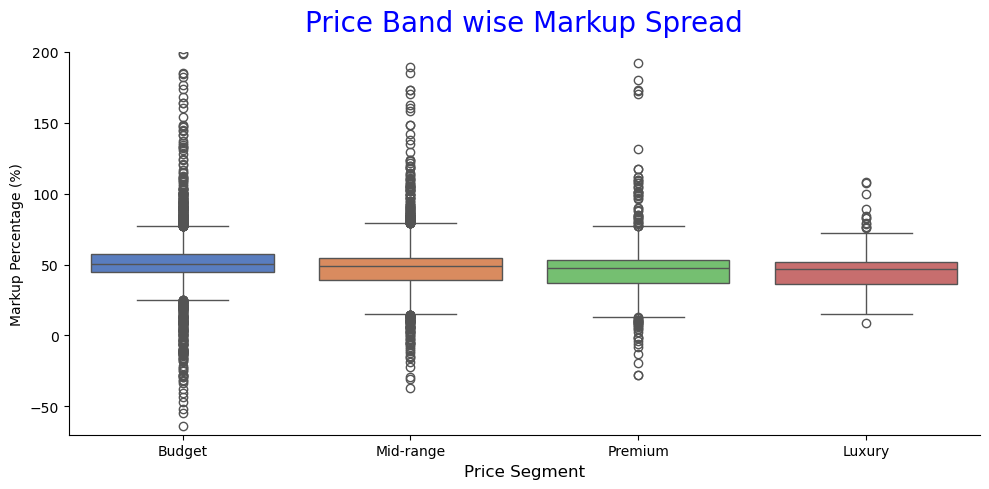

In [13]:
# Price Segment wise markup distribution
plt.figure(figsize=(10,5))

sns.boxplot(data= product_summary,x='PriceSegment', y='Markup_perc', hue='PriceSegment',
            palette='muted')

plt.title('Price Band wise Markup Spread', color='blue', fontsize=20, pad=15)
plt.ylabel('Markup Percentage (%)')
plt.xlabel('Price Segment', fontsize=12)
plt.ylim(-70,200)

sns.despine()
plt.tight_layout()
plt.show()

> - Markup distribution is broadly similar across all price segments, with medians around 45–50% , indicating markup is not strongly price tier driven, but likely governed by a uniform margin strategy.

> - Budget segment shows the highest variability,with Mid-range and Premium segments being more stable and consistent markup spread and Luxury segment has slightly tighter distribution.

> - Extreme values (negative and very high markup %) are predominantly concentrated in the Budget segment, with fewer such cases in higher segments, indicating that pricing inefficiencies, heavy discounting, or opportunistic high margin pricing are more common in lower price tiers, while higher segments maintain better pricing discipline.

#### Do Bulk Orders Reduce Unit Cost?

In [14]:
purchase_trans['UnitCost'] = purchase_trans['PurchaseDollars'] / purchase_trans['PurchaseQuantity']

# Segmentation based on Purchase Volume
bins= [0,50,500,5000,20000,float('inf')]
labels=['Very Small','Small','Medium','Large','Bulk']
purchase_trans['PurchaseOrderSize'] = pd.cut(purchase_trans['PurchaseQuantity'], bins=bins, 
                                             labels= labels)

# Unit Cost distribution per segment
cost_analysis = purchase_trans.groupby('PurchaseOrderSize', observed=False).apply(lambda x: pd.Series({
        'Weighted_Average': x['PurchaseDollars'].sum() / x['PurchaseQuantity'].sum(),
        'Median': x['UnitCost'].median(),
        'P25': x['UnitCost'].quantile(0.25),
        'P75': x['UnitCost'].quantile(0.75)
    }), include_groups =False).reset_index(names='Order Size')

print('Purchase Volume impact on Unit Cost : ')
display(cost_analysis.style.format({'Median': '${:.2f}','P25': '${:.2f}',
                                    'P75': '${:.2f}','Weighted_Average': '${:.2f}'}))

Purchase Volume impact on Unit Cost : 


,Order Size,Weighted_Average,Median,P25,P75
0,Very Small,$15.33,$14.05,$8.68,$21.32
1,Small,$12.47,$11.40,$8.42,$15.40
2,Medium,$10.87,$9.40,$7.60,$12.65
3,Large,$9.52,$7.88,$6.86,$10.88
4,Bulk,$9.40,$8.74,$6.97,$11.40


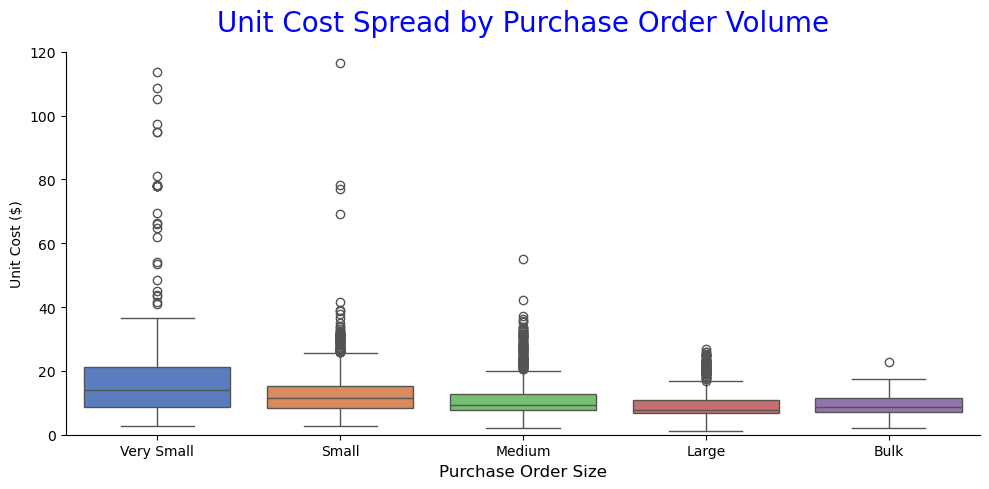

In [15]:
plt.figure(figsize=(10,5))

sns.boxplot(data= purchase_trans,x='PurchaseOrderSize', y='UnitCost', hue='PurchaseOrderSize',
            palette='muted')

plt.title('Unit Cost Spread by Purchase Order Volume', color='blue', fontsize=20, pad=15)
plt.ylabel('Unit Cost ($)')
plt.xlabel('Purchase Order Size', fontsize=12)
plt.ylim(0,120)

sns.despine()
plt.tight_layout()
plt.show()

> - There is a clear inverse relationship between order size and unit cost, where increasing purchase volume consistently reduces per unit cost. The weighted average drops significantly from $15.33 (Very Small) to $9.52 (Large), highlighting strong impact of order scale on procurement cost.

> - Smaller order sizes show higher cost variability and wider spread, as seen in both quartiles and the box plot indicating inconsistent procurement pricing or weaker negotiation power at low volumes.

> - Volume based pricing is effective, but most cost efficiency is already captured at the “Large” order level.Pushing for Bulk orders may not significantly improve margins, while it can increase inventory holding risk.

#### Product Pricing Opportunity
- High Sell Through , Low Markup -> Increase Price
- High Sell Through , High Markup -> Maintain Price
- Low Sell Through , Low Markup -> Investigate
- Low Sell Through , High Markup -> Reduce Price

In [16]:
conditions = [(product_summary['SellThroughRatio'] >= 0.8) & (product_summary['Markup_perc'] < 50),
                (product_summary['SellThroughRatio'] >= 0.8) & (product_summary['Markup_perc'] >= 50),
                (product_summary['SellThroughRatio'] < 0.8) & (product_summary['Markup_perc'] >= 50),
                (product_summary['SellThroughRatio'] < 0.8) & (product_summary['Markup_perc'] < 50)]
labels = ['Increase Price','Maintain Price','Reduce Price','Investigate']

product_summary['PricingAction'] = np.select(conditions, labels ,default='Unknown')

product_summary.groupby('PricingAction').agg(
    No_of_Products = ('Description', 'count'),
    RevenueShare = ('SalesContribution','sum')
).reset_index().style.format({'RevenueShare': '{:.2f}%'})

,PricingAction,No_of_Products,RevenueShare
0,Increase Price,3221,58.37%
1,Investigate,2398,8.57%
2,Maintain Price,2544,26.69%
3,Reduce Price,2299,6.37%


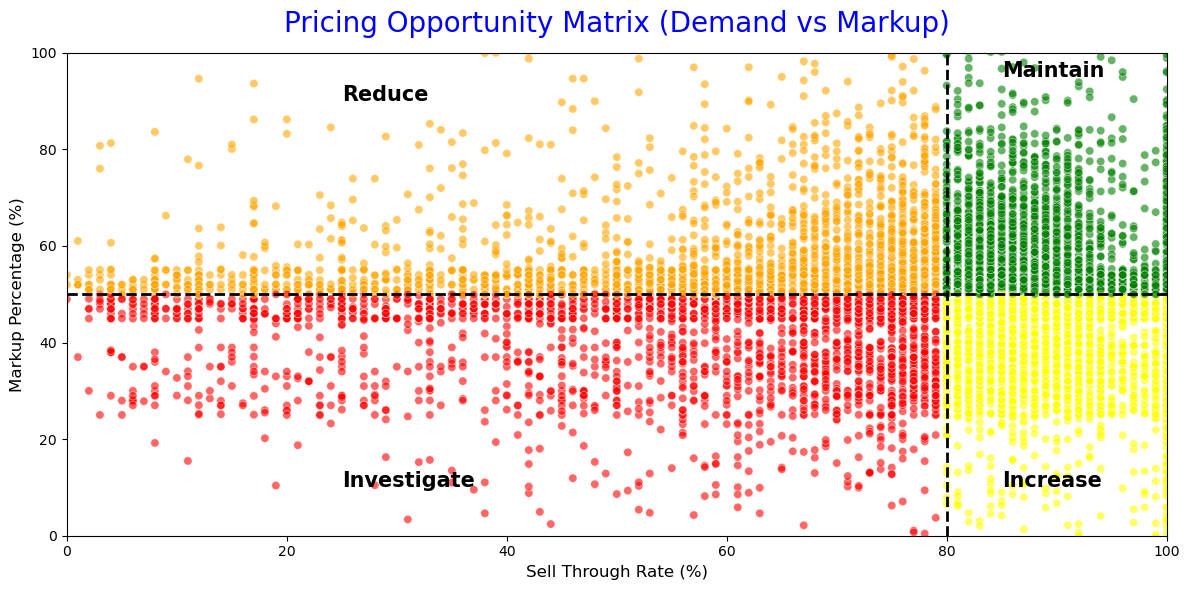

In [17]:
plt.figure(figsize=(12,6))

sns.scatterplot(data= product_summary,x='SellThroughRatio', y='Markup_perc', hue='PricingAction',
            palette={'Increase Price':'yellow','Reduce Price':'orange','Maintain Price':'green','Investigate':'red'},
            legend=None, alpha=0.6)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos : int(x*100)))

plt.axvline(x=0.8, color='black', linestyle='--', linewidth=2)
plt.axhline(y=50, color='black', linestyle='--', linewidth=2)

plt.text(0.85, 95, 'Maintain', fontsize=15, fontweight = 'bold')
plt.text(0.85, 10, 'Increase', fontsize=15,fontweight = 'bold')
plt.text(0.25, 90, 'Reduce', fontsize=15,fontweight = 'bold')
plt.text(0.25, 10, 'Investigate', fontsize=15,fontweight = 'bold')

plt.title('Pricing Opportunity Matrix (Demand vs Markup)', color='blue', fontsize=20, pad=15)
plt.ylabel('Markup Percentage (%)', fontsize=12)
plt.xlabel('Sell Through Rate (%)', fontsize=12)
plt.ylim(0,100)
plt.xlim(0,1)

plt.tight_layout()
plt.show()

> - 58% of revenue comes from products where prices can be increased, meaning many products are selling fast but priced too low ,indicating opportunity to increase profit.

> - 27% of revenue is from correctly priced products, which should be kept steady as they perform well and only around 6% of revenue needs price reduction, so most products are not overpriced and can handle price increases.Products with low demand and low markup % are showing inconsistent pricing need review.

> - Current pricing is volume driven, data suggests shifting toward a margin optimization strategy through controlled price increase.

#### Vendor Pricing Negotiation
- High Cost than Segment Average , Low Margin than Segment Average  -> Immediate Negotiation
- High Cost than Segment Average , High Margin than Segment Average  -> Negotiation Opportunity
- Low Cost than Segment Average , Low Margin than Segment Average  -> No Negotiation (Pricing Issue)
- Low Cost than Segment Average , High Margin than Segment Average  -> No Negotiation (Strategic Vendor) 

In [18]:
dataset['SalesPrice_perml'] = dataset['SalesPrice']/ dataset['Volume_ml']
dataset['PurchasePrice_perml'] = dataset['PurchasePrice']/ dataset['Volume_ml']

# Segmentation based on selling price
dataset['PriceSegment'] = pd.qcut(dataset['SalesPrice_perml'], q=[0,0.4,0.75,0.95,1], 
                                        labels= ['Budget', 'Mid-range', 'Premium', 'Luxury'])

# Price Segment wise avg cost and avg margin  
segment_unitcost = dataset.groupby('PriceSegment',observed=False).apply(lambda x: pd.Series({
                     'Segment_AvgPurchasePrice_perml' : x['PurchasePrice'].sum()/ x['Volume_ml'].sum(),
                     'Segment_AvgProfitMargin' : x['GrossProfit'].sum()*100/x['TotalSalesDollars'].sum()}),
                     include_groups =False).reset_index()

# Comparing Segment wise cost and margin with SKU level cost and margin
dataset = dataset.drop(columns= ['Segment_AvgPurchasePrice_perml','Segment_AvgProfitMargin'] ,errors='ignore')
dataset = dataset.merge(segment_unitcost, on='PriceSegment', how='left')

# Cost Gap % = (cost- segment avg cost)*100/ (segment avg cost)
dataset['CostGapPerc'] = ((dataset['PurchasePrice_perml'] - dataset['Segment_AvgPurchasePrice_perml']) 
                            / dataset['Segment_AvgPurchasePrice_perml'])

# Margin Gap = Margin - Segment Avg Margin
dataset['MarginGap'] = dataset['GrossProfitMargin'] - dataset['Segment_AvgProfitMargin']

# Vendor level Cost Gap and Margin Gap
vendor_summary = dataset.groupby('VendorName').apply(lambda x: pd.Series({
                     'Weighted_CostGap': ((x['CostGapPerc'] * x['TotalQuantityPurchased']*x['Volume_ml']).sum() /
                                              (x['TotalQuantityPurchased']*x['Volume_ml']).sum()),
                     'Weighted_MarginGap': ((x['MarginGap'] * x['TotalSalesDollars']).sum() / 
                                             x['TotalSalesDollars'].sum()),
                     'TotalSales' : x['TotalSalesDollars'].sum()}),
                     include_groups =False).reset_index()

In [19]:
# Revenue Share per Vendor
vendor_summary['SalesContribution'] = vendor_summary['TotalSales'] *100/ vendor_summary['TotalSales'].sum()

# Segmentation for Negotiation strategy
conditions = [(vendor_summary['Weighted_CostGap'] > 0) & (vendor_summary['Weighted_MarginGap'] < 0),
                (vendor_summary['Weighted_CostGap'] >0) & (vendor_summary['Weighted_MarginGap'] >=0),
                (vendor_summary['Weighted_CostGap'] <=0) & (vendor_summary['Weighted_MarginGap'] < 0),
                (vendor_summary['Weighted_CostGap'] <=0) & (vendor_summary['Weighted_MarginGap'] >=0)]

labels = ['Immediate Negotiation','Negotiation Opportunity',
          'No Negotiation (Fix Pricing)','No Negotiation (Strategic Vendor)']

vendor_summary['NegotiationAction'] = np.select(conditions,labels,default='Unknown')
vendor_summary.groupby('NegotiationAction').agg(
    No_of_Vendors = ('VendorName', 'count'),
    RevenueShare = ('SalesContribution','sum')
).reset_index().style.format({'RevenueShare': '{:.2f}%'})

,NegotiationAction,No_of_Vendors,RevenueShare
0,Immediate Negotiation,40,51.88%
1,Negotiation Opportunity,33,16.55%
2,No Negotiation (Fix Pricing),19,7.57%
3,No Negotiation (Strategic Vendor),33,24.00%


> - 40 vendors categorized under 'Immediate Negotiation' contribute 51.8% of revenue,the 'Negotiation Opportunity' group adds another 16.5% revenue, indicating high negotiation leverage concentration and a strong opportunity to directly improve margins by prioritizing renegotiation.

> - 19 vendors (~ 7.5% revenue) marked as 'No Negotiation (Fix Pricing)' indicate internal pricing gaps rather than vendor issues and require price correction instead of negotiation.

> - 33 vendors fall under 'No Negotiation (Strategic Vendors)', implying the need to protect strong relationships and keep supply stable while focusing on negotiable segments.

# Key Insights

#### 1. Business is heavily skewed towards lower price segments with limited premium margin realization
- Budget segment drives the majority of sales, purchases, and profit, anchoring overall performance.
- Mid-range operates at scale but delivers weaker ROI, indicating margin optimization opportunity.
- Premium and Luxury segments show low margins reflecting ineffective premium pricing and limited value capture.

#### 2. Pricing strategy is positive but constrained by narrow margins

Sales prices are consistently higher than purchase prices, confirming a stable markup strategy.However, significant overlap between the distributions indicates that most products operate on tight margins, limiting profitability and highlighting the need to optimize lower margin segments.

#### 3. Markup strategy is differentiated by pack size but largely uniform across price segments

- Markup varies across size segments, with Bulk packs commanding the highest margins while Small and Large packs remain more competitively priced, positioning Standard as the pricing benchmark.
- In contrast, markup remains broadly consistent across price segments (~ 45–50%) indicating a uniform margin strategy irrespective of price tier. However, higher variability and extreme pricing cases in the Budget segment suggest pricing inefficiencies, while Premium and Luxury segments demonstrate tighter control and better pricing discipline.

#### 4. Bulk purchasing reduces unit cost but with diminishing returns at higher volumes

Unit cost declines significantly as order size increases confirming strong benefits of volume based procurement. However, most cost efficiency is realized by the Large order level, with limited additional gains from Bulk purchases. Smaller orders exhibit higher cost variability, indicating inconsistent pricing and weaker negotiation leverage at low volumes, while excessive bulk buying may introduce inventory risk without proportional margin benefit.

#### 5.Significant pricing opportunity exists with scope to shift focus from volume to margin

A large share of revenue (around 58%) comes from underpriced and high-performing products, indicating strong potential to increase prices and improve profitability. Only a small portion requires price reduction, while most products are either correctly priced or can absorb increases. This tells that the current strategy is volume driven, with a clear opportunity to shift towards margin optimization through controlled price increases.

#### 6. Vendor base presents strong margin improvement opportunity through targeted negotiation

A significant share of revenue (~68%) is concentrated in vendors requiring immediate or potential negotiation  highlighting opportunity to improve margins. A small subset of vendors reflects internal pricing gaps rather than negotiation scope requiring price correction instead. Strategic vendors(non negotiable) must be managed carefully to ensure supply stability while focusing efforts on high impact negotiable vendors.

---